In [ ]:
# Collection library, runs in terminal because of "!"
!pip install bing-image-downloader
# Not used for this projcet. Because of not enough data.
# Instead of, used this dataset: https://www.kaggle.com/datasets/ashwingupta3012/human-faces

### Upload `haarcascade_frontalface_default.xml`
Please upload the `haarcascade_frontalface_default.xml` file. This file is essential for face detection.

# 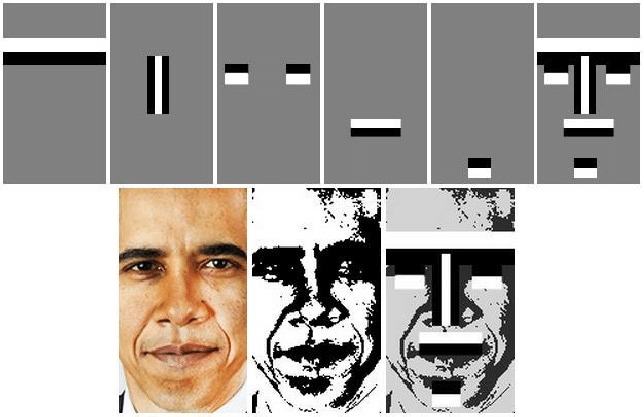

In [3]:
!pip install opencv-python tqdm numpy

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.3 MB 5.3 MB/s eta 0:00:03
   ------ --------------------------------- 2.1/12.3 MB 5.3 MB/s eta 0:00:02
   ------------ --------------------------- 3.9/12.3 MB 6.5 MB/s eta 0:00:02
   ------------------ --------------------- 5.8/12.3 MB 7.2 MB/s eta 0:00:01
   ------------------------ --------------- 7.6/12.3 MB 7.6 MB/s eta 0:00:01
   ------------------------------- -------- 9.7/12.3 MB 7.9 MB/s eta 0:00:01
   ------------------------------------- -- 11.5/12.3 MB 8.1 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 8

In [ ]:
# Let's use a dataset from Kaggle, because bing image downloader does not worked well
# For extracting faces,use the "classifier".It has features itself for detecting face from image.
# https://github.com/kipr/opencv/blob/master/data/haarcascades/haarcascade_frontalface_default.xml
# Download the xml document. Then uplod into Colab.
# You may think haar-like features as CNN filters. Each filters corresponds to a different feature.

import cv2
face_cascade=cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# Access the images.
import os
from  tqdm import tqdm
import numpy as np

shape=64 # After resizing, the image shape that only contains "face".
channel=3
data=[]
directory=r"C:\Users\ASUS\Desktop\Projects\HumanFaces\directory"
for pic in tqdm(os.listdir(directory)):
  pic=os.path.join(directory,pic)
  img=cv2.imread(pic,cv2.IMREAD_COLOR)

  if(img is not None): # Face detection work with non-colored images.
    gray_image=cv2.cvtColor(img,cv2.COLOR_RGB2GRAY)
    # Parameters for detecting face
    # 'minNeighbors=8' for how many neighbor rectangle do we want for labeling the are to "face". You can change it as you want.
    faces=face_cascade.detectMultiScale(gray_image,1.25, 8)

    for f in faces:
      x,y,w,h= [ v for v in f] # w for 'width', h for 'height'
      face_crop=img[y:y+h,x:x+w] # For opencv , first write Y then write X
      resized=cv2.resize(face_crop,(shape,shape)) # Neural networks mostly works with squares. You are not obliged to use.
      data.append(resized)






100%|██████████| 7219/7219 [04:09<00:00, 28.92it/s]


In [8]:
!pip install matplotlib

  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.3 MB 6.0 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 7.0 MB/s  0:00:00
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl (7.1 MB)
Using cached pyparsing-3.3.2-py3-none-any.w

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9607843..0.92941177].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..0.96862745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.79607844..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the va

<function matplotlib.pyplot.show(close=None, block=None)>

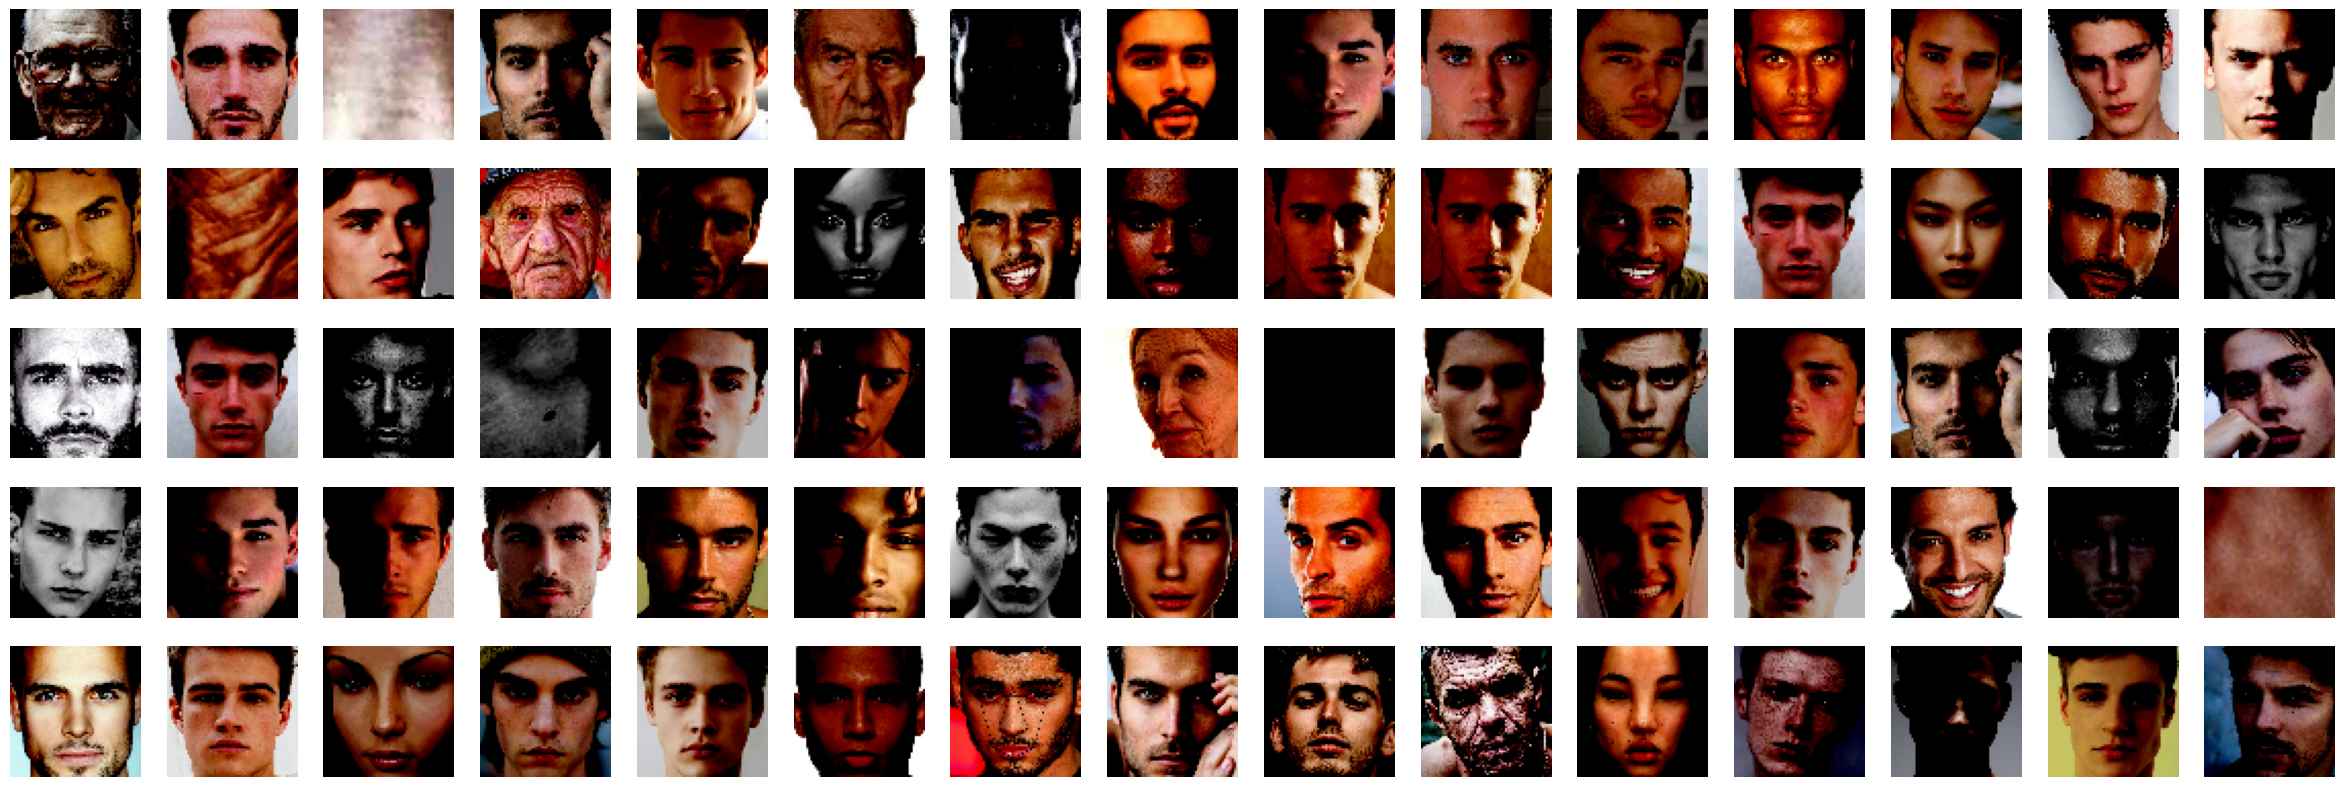

In [23]:

import matplotlib.pyplot as plt

fig=plt.figure(figsize=(30,10))
for i in range(75):
  plt.subplot(5,15,i+1)
  plt.imshow(cv2.cvtColor(data[i],cv2.COLOR_BGR2RGB))
  plt.axis('off')

plt.show

In [ ]:
import numpy  as np
# Converting numpy array because it is fast and runs directly in RAM.
data=np.array(data).reshape(-1,shape,shape,channel).astype('float32') # -1 stands for scalability.
#It basicly means "I will convert the data[0] to number of images.Even if don't know the size."
data=(data-127.5) / 127.5 # Normalizing array. 
# [0,255] --> [-1,1]

In [ ]:
data.shape  #Our data contains 5082 image, 64x64 and RGB 

(5082, 64, 64, 3)

In [ ]:
import pickle
# Save the "data numpy array" as pkl. 
# Saving as 'wb' b for "binary".
pickle.dump(data,open("faces.pkl","wb"))

# Upload data

# data = pickle.load("faces.pkl")


*Prepared data successfully.Then run this data through GAN.* 

In [29]:
!pip install tensorflow


In [27]:
import tensorflow as tf

# Converting data to tensor.
# Slice the data into batches. So we can utilize the GPUs parallel computation.
BATCH_SIZE= 256
data=tf.data.Dataset.from_tensor_slices(data).batch(BATCH_SIZE)

![alt text](0_eeYJwyNgOzn4smHx.jpg)

In [45]:
from tensorflow.keras  import layers 
# This cell contains implementing Generator network
# Generator network,generates images from noise.

NOISE_SIZE= 100 # How many images do we want to generate an image
# It is a hyperparameter

initializer=tf.random_normal_initializer(0.,0.02) # Mean,variation

gen=tf.keras.Sequential() # Layers into a single stack

gen.add(layers.Dense(4*4*512,use_bias=False, input_shape=(NOISE_SIZE,)))
# 4 width 4 height 512 number of generations 
gen.add(layers.BatchNormalization()) # For generalization
gen.add(layers.LeakyReLU()) # Learns negatives also

gen.add(layers.Reshape((4,4,512))) # For convolution 

gen.add(layers.Conv2DTranspose(512,(3,3), strides=(1,1),padding='same',kernel_initializer=initializer,use_bias=False))
 # Not using bias because of computational cost.       
gen.add(layers.BatchNormalization()) 
gen.add(layers.LeakyReLU()) 

gen.add(layers.Conv2DTranspose(256,(5,5), strides=(2,2),padding='same',kernel_initializer=initializer,use_bias=False))
gen.add(layers.BatchNormalization()) 
gen.add(layers.LeakyReLU()) 

gen.add(layers.Conv2DTranspose(64,(5,5), strides=(2,2),padding='same',kernel_initializer=initializer,use_bias=False))
gen.add(layers.BatchNormalization()) 
gen.add(layers.LeakyReLU()) 

gen.add(layers.Conv2DTranspose(64,(5,5), strides=(2,2),padding='same',kernel_initializer=initializer,use_bias=False))
gen.add(layers.BatchNormalization()) 
gen.add(layers.LeakyReLU()) 

gen.add(layers.Conv2DTranspose(channel,(5,5),strides=(2,2),padding='same',kernel_initializer=initializer,use_bias=False,activation="tanh"))
# Tanh range (-1,1) 
# It more utility for computations
  




tf.Tensor(
[[-6.76864907e-02  1.96754754e+00 -7.15574443e-01  2.27462435e+00
   6.52301252e-01  1.63976705e+00 -1.77495182e+00  1.13186443e+00
   8.39107513e-01  9.53856885e-01  7.88132966e-01  8.86664093e-01
   4.13392931e-01 -7.83368111e-01  4.43934619e-01 -7.82459319e-01
   1.74510539e-01  2.74785627e-02 -9.52945471e-01 -2.60260850e-01
   1.06694974e-01 -7.72612572e-01  6.85334444e-01  7.84398675e-01
   1.26979911e+00  1.61250210e+00 -1.84242249e+00  3.71870428e-01
  -1.47945419e-01 -2.72266120e-01 -1.90207148e+00 -4.59557593e-01
  -4.99189705e-01 -1.24295437e+00  1.94198024e+00  6.28877759e-01
  -7.49291718e-01 -1.93048465e+00  5.13735831e-01  1.19753575e+00
  -3.37188333e-01 -8.64241645e-03 -1.68461728e+00 -7.78351068e-01
  -6.35795593e-01  1.39364064e-01 -3.33351046e-01  1.53440014e-01
  -9.80123281e-01 -8.34416926e-01 -1.98649561e+00 -1.18818915e+00
  -3.10784370e-01 -1.09752908e-01  1.60612273e+00  7.82676637e-01
  -8.10204804e-01  7.70471156e-01  1.93829253e-01  6.44643903e-01

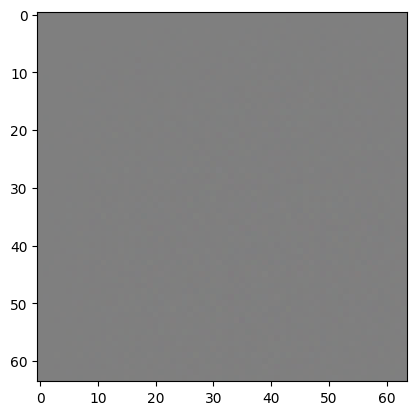

In [48]:
noise=tf.random.normal([1,100])
print(noise)
test_image= gen(noise,training=False)
plt.imshow(cv2.cvtColor((test_image[0]*127.5 + 127.5).numpy().reshape(shape,shape,channel).astype('uint8'),cv2.COLOR_BGR2RGB))

This cell contains Discriminator network implementation